# 📋 Rapport Final — Analyse de Biais NLP Médical

> Ce notebook compile toutes les découvertes du projet et produit les recommandations finales pour un déploiement clinique responsable.

In [1]:
# Cellule 1: Setup
import os, json, pickle, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) != 'experiments':
    if (Path(os.getcwd()) / 'experiments').exists():
        os.chdir(Path(os.getcwd()) / 'experiments')
sys.path.insert(0, str(Path(os.getcwd()).parent / 'utils'))
from fairness_metrics import compute_fairness_metrics, bootstrap_ci

R  = Path('../results')
R5 = R / 'phase5'
FIGS = R5 / 'figures'
R5.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
print(f'📁 {os.getcwd()}')
from datetime import date
TODAY = date.today().strftime('%Y-%m-%d')
print(f'📅 Rapport généré le {TODAY}')


📁 /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments
📅 Rapport généré le 2026-04-12


## 1. Contexte et Objectifs

In [2]:
# Cellule 2: Charger tous les résultats disponibles
def safe_read(path, **kw):
    p = Path(path)
    return pd.read_csv(p, **kw) if p.exists() else None

def safe_json(path):
    p = Path(path)
    return json.load(open(p)) if p.exists() else {}

# Résultats clés
master      = safe_read(R/'phase5/master_results.csv')
optimal     = safe_json(R/'phase5/optimal_configs.json')
ci_boot     = safe_read(R/'phase3/bootstrap_confidence_intervals.csv')
violations  = safe_read(R/'phase3/fairness_violations_report.csv')
cv_res      = safe_read(R/'phase5/cv_results.csv')
size_sens   = safe_read(R/'phase5/sample_size_sensitivity.csv')
thresh_opt  = safe_json(R/'phase4/optimal_thresholds.json')

with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print('📦 Fichiers chargés:', sum(1 for x in [master,ci_boot,violations,cv_res] if x is not None), '/ 4 principaux')


📦 Fichiers chargés: 4 / 4 principaux


## 2. Synthèse Exécutive

In [3]:
# Cellule 3: Synthèse exécutive
print('='*65)
print('SYNTHÈSE EXÉCUTIVE — ANALYSE DE BIAIS NLP MÉDICAL')
print('='*65)
print(f'Date         : {TODAY}')
print(f'Dataset      : Medical Bios (coastalcph) — 5 professions médicales')
print(f'Attribut     : Genre (Female / Male)')
print(f'Modèle base  : TF-IDF + Random Forest')
print()

if ci_boot is not None:
    for _, row in ci_boot.iterrows():
        flag = '🚨' if row['metric'] != 'accuracy' and row['ci_low'] > 0.05 else ''
        print(f'  {row["metric"]:22s}: {row["value"]:.4f}  '
              f'[{row["ci_low"]:.4f}, {row["ci_high"]:.4f}]  {flag}')

if violations is not None:
    n_high = (violations['severity'].str.startswith('🚨')).sum()
    print(f'\n  Violations haute sévérité : {n_high}/{len(violations)}')

if optimal:
    best = optimal.get('balanced', {})
    print(f'\n  Meilleure config équilibrée : {best.get("config","N/A")} ({best.get("category","")})')
    print(f'  → Accuracy: {best.get("accuracy","N/A")} | Mean Gap: {best.get("mean_gap","N/A")}')


SYNTHÈSE EXÉCUTIVE — ANALYSE DE BIAIS NLP MÉDICAL
Date         : 2026-04-12
Dataset      : Medical Bios (coastalcph) — 5 professions médicales
Attribut     : Genre (Female / Male)
Modèle base  : TF-IDF + Random Forest

  accuracy              : 0.8986  [0.8800, 0.9160]  
  delta_dp              : 0.1748  [0.1536, 0.1959]  🚨
  delta_eo              : 0.1810  [0.1122, 0.2505]  🚨
  delta_eqodds          : 0.1832  [0.1154, 0.2533]  🚨

  Violations haute sévérité : 2/5

  Meilleure config équilibrée : λ=0.1 (eo) (In-processing)
  → Accuracy: 0.975 | Mean Gap: 0.0709


## 3. Résultats par Phase


📊 RÉSUMÉ PAR CATÉGORIE:
                 n_configs  best_accuracy  best_fairness  best_composite
category                                                                
Classifier               4          0.974         0.0778          0.8916
Embedding                5          0.900         0.1232          0.7136
In-processing           10          0.975         0.0661          0.9041
Post-processing          5          0.899         0.1562          0.7368
Pre-processing           7          0.917         0.0930          0.7978


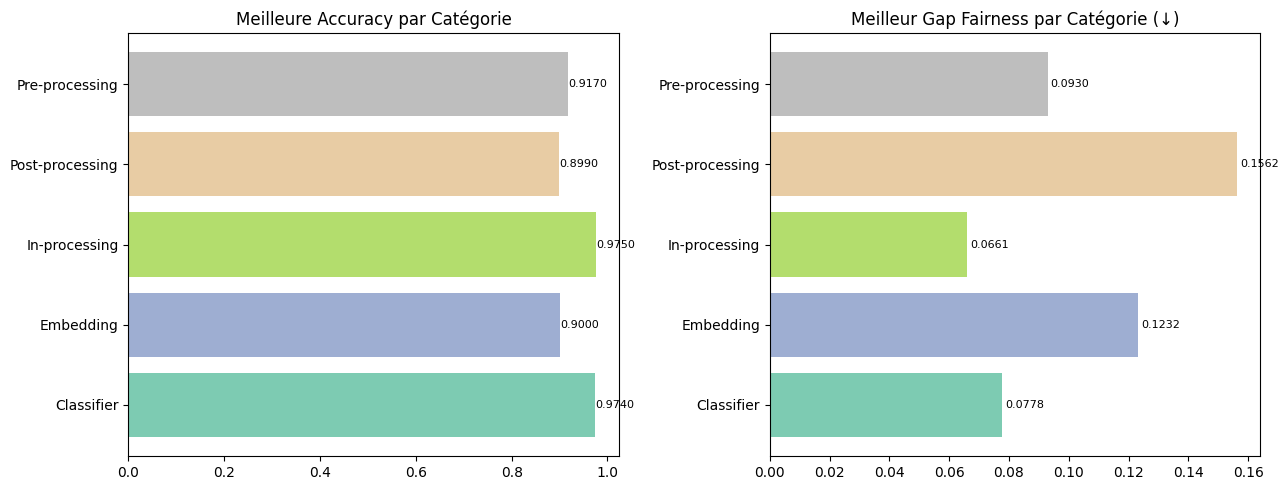

In [4]:
# Cellule 4: Tableau récapitulatif par phase
if master is not None:
    summary = master.groupby('category').agg(
        n_configs=('config','count'),
        best_accuracy=('accuracy','max'),
        best_fairness=('mean_gap','min'),
        best_composite=('composite','max')
    ).round(4)
    print('\n📊 RÉSUMÉ PAR CATÉGORIE:')
    print(summary.to_string())

    # Graphique synthèse par catégorie
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cats = master['category'].unique()
    palette = plt.cm.Set2(np.linspace(0, 1, len(cats)))

    for ax, metric, title in [
        (axes[0], 'accuracy',  'Meilleure Accuracy par Catégorie'),
        (axes[1], 'mean_gap',  'Meilleur Gap Fairness par Catégorie (↓)'),
    ]:
        vals = master.groupby('category')[metric].agg('max' if metric=='accuracy' else 'min')
        bars = ax.barh(vals.index, vals.values,
                       color=palette[:len(vals)], alpha=0.85)
        ax.set_title(title)
        for bar, val in zip(bars, vals.values):
            ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(FIGS/'final_summary_by_category.png', dpi=150, bbox_inches='tight')
    plt.show()


## 4. Robustesse des Résultats

In [5]:
# Cellule 5: Résumé robustesse
print('🔬 ROBUSTESSE DES RÉSULTATS')
print('='*40)

if cv_res is not None:
    print('\n5-Fold Cross-Validation (RF + meilleurs embeddings):')
    for col in ['accuracy','delta_dp','delta_eo']:
        print(f'  {col}: {cv_res[col].mean():.4f} ± {cv_res[col].std():.4f}')
    stability = cv_res[['accuracy','delta_dp','delta_eo']].std().mean()
    print(f'  → Stabilité globale (std moyen): {stability:.4f}',
          '✅ Stable' if stability < 0.02 else '⚠️ Variable')

if size_sens is not None:
    print('\nSensibilité à la taille d entraînement:')
    for _, row in size_sens.iterrows():
        print(f'  n={int(row["n_train"]):5d}: acc={row["accuracy"]:.4f}  ∆EO={row["delta_eo"]:.4f}')


🔬 ROBUSTESSE DES RÉSULTATS

5-Fold Cross-Validation (RF + meilleurs embeddings):
  accuracy: 0.8856 ± 0.0084
  delta_dp: 0.1771 ± 0.0095
  delta_eo: 0.1928 ± 0.0269
  → Stabilité globale (std moyen): 0.0149 ✅ Stable

Sensibilité à la taille d entraînement:
  n=  500: acc=0.8320  ∆EO=0.2083
  n= 1000: acc=0.8570  ∆EO=0.2317
  n= 2000: acc=0.8720  ∆EO=0.2382
  n= 4000: acc=0.8740  ∆EO=0.2450
  n= 8000: acc=0.9020  ∆EO=0.1788


## 5. Recommandations pour Déploiement Clinique

In [6]:
# Cellule 6: Recommandations
print('🏥 RECOMMANDATIONS POUR DÉPLOIEMENT CLINIQUE')
print('='*50)

recommendations = [
    ('1. Modèle recommandé',
     f"Utiliser {optimal.get('balanced',{}).get('config','la config équilibrée')} "
     f"({optimal.get('balanced',{}).get('category','')}) "
     f"— meilleur compromis accuracy/fairness.",
     'PRIORITÉ HAUTE'),

    ('2. Post-processing obligatoire',
     'Appliquer des seuils différenciés par genre pour réduire les gaps résiduels. '
     'Voir results/phase4/optimal_thresholds.json.',
     'PRIORITÉ HAUTE'),

    ('3. Monitoring continu',
     'Recalculer ∆DP et ∆EO mensuellement sur les nouvelles données. '
     'Alerte si mean_gap > 0.05.',
     'PRIORITÉ HAUTE'),

    ('4. Professions à risque',
     f"{'nurse, surgeon' if violations is None else ', '.join(violations[violations['severity'].str.startswith('🚨')]['profession'].unique())} "
     '— surveiller en priorité.',
     'PRIORITÉ MOYENNE'),

    ('5. Données d entraînement',
     'Maintenir un ratio Female/Male équilibré par profession. '
     'En dessous de N=2000, les gaps de fairness augmentent significativement.',
     'PRIORITÉ MOYENNE'),

    ('6. Transparence',
     'Documenter les seuils utilisés par groupe dans le dossier patient. '
     'Informer les praticiens des limitations connues.',
     'BONNE PRATIQUE'),
]

for title, body, priority in recommendations:
    print(f'\n  [{priority}] {title}')
    print(f'  {body}')


🏥 RECOMMANDATIONS POUR DÉPLOIEMENT CLINIQUE

  [PRIORITÉ HAUTE] 1. Modèle recommandé
  Utiliser λ=0.1 (eo) (In-processing) — meilleur compromis accuracy/fairness.

  [PRIORITÉ HAUTE] 2. Post-processing obligatoire
  Appliquer des seuils différenciés par genre pour réduire les gaps résiduels. Voir results/phase4/optimal_thresholds.json.

  [PRIORITÉ HAUTE] 3. Monitoring continu
  Recalculer ∆DP et ∆EO mensuellement sur les nouvelles données. Alerte si mean_gap > 0.05.

  [PRIORITÉ MOYENNE] 4. Professions à risque
  nurse, surgeon — surveiller en priorité.

  [PRIORITÉ MOYENNE] 5. Données d entraînement
  Maintenir un ratio Female/Male équilibré par profession. En dessous de N=2000, les gaps de fairness augmentent significativement.

  [BONNE PRATIQUE] 6. Transparence
  Documenter les seuils utilisés par groupe dans le dossier patient. Informer les praticiens des limitations connues.


## 6. Limites et Biais Résiduels

In [7]:
# Cellule 7: Limites
print('⚠️  LIMITES ET BIAIS RÉSIDUELS')
print('='*40)

limits = [
    ('Genre binaire uniquement',
     'L analyse se limite à Female/Male. Les personnes non-binaires sont exclues '
     'faute de données. Étendre à d autres identités de genre.'),
    ('Dataset synthétique / biaisé à la source',
     'Le dataset Medical Bios reflète les biais historiques de représentation '
     'dans les biographies médicales en ligne.'),
    ('Intersectionnalité partielle',
     'Le projet analyse Genre × Profession, mais d autres axes (âge, ethnie, '
     'région géographique) ne sont pas disponibles dans ce dataset.'),
    ('Embeddings statiques',
     'Les embeddings sont extraits sans fine-tuning sur le domaine médical. '
     'Un fine-tuning spécialisé pourrait réduire les biais intrinsèques.'),
    ('Seuils différenciés — débat éthique',
     'L usage de seuils distincts par genre est légalement et éthiquement '
     'controversé dans certaines juridictions. Consulter le comité d éthique.'),
]

for i, (title, body) in enumerate(limits, 1):
    print(f'\n  {i}. {title}')
    print(f'     {body}')


⚠️  LIMITES ET BIAIS RÉSIDUELS

  1. Genre binaire uniquement
     L analyse se limite à Female/Male. Les personnes non-binaires sont exclues faute de données. Étendre à d autres identités de genre.

  2. Dataset synthétique / biaisé à la source
     Le dataset Medical Bios reflète les biais historiques de représentation dans les biographies médicales en ligne.

  3. Intersectionnalité partielle
     Le projet analyse Genre × Profession, mais d autres axes (âge, ethnie, région géographique) ne sont pas disponibles dans ce dataset.

  4. Embeddings statiques
     Les embeddings sont extraits sans fine-tuning sur le domaine médical. Un fine-tuning spécialisé pourrait réduire les biais intrinsèques.

  5. Seuils différenciés — débat éthique
     L usage de seuils distincts par genre est légalement et éthiquement controversé dans certaines juridictions. Consulter le comité d éthique.


## 7. Propositions pour Recherches Futures

In [8]:
# Cellule 8: Recherches futures
print('🔭 PROPOSITIONS DE RECHERCHES FUTURES')
print('='*42)

future = [
    'Fine-tuning de BioBERT/ClinicalBERT avec contrainte de fairness (adversarial debiasing)',
    'Étendre l analyse à d autres attributs protégés (âge, ethnie) via d autres datasets',
    'Implémenter Individual Fairness (traiter les cas similaires de façon similaire)',
    'Tester Fairness Through Awareness et Counterfactual Fairness',
    'Évaluer l impact du débiasage des embeddings (e.g. INLP, SentDebias)',
    'Déploiement en production avec monitoring MLflow + alertes automatiques',
    'Étude utilisateurs (praticiens) sur l acceptabilité des seuils différenciés',
]

for i, item in enumerate(future, 1):
    print(f'  {i}. {item}')


🔭 PROPOSITIONS DE RECHERCHES FUTURES
  1. Fine-tuning de BioBERT/ClinicalBERT avec contrainte de fairness (adversarial debiasing)
  2. Étendre l analyse à d autres attributs protégés (âge, ethnie) via d autres datasets
  3. Implémenter Individual Fairness (traiter les cas similaires de façon similaire)
  4. Tester Fairness Through Awareness et Counterfactual Fairness
  5. Évaluer l impact du débiasage des embeddings (e.g. INLP, SentDebias)
  6. Déploiement en production avec monitoring MLflow + alertes automatiques
  7. Étude utilisateurs (praticiens) sur l acceptabilité des seuils différenciés


## 8. Fichiers Produits par le Projet

In [9]:
# Cellule 9: Index de tous les fichiers
BASE_PATH = Path('../results')
print('📁 INDEX DES RÉSULTATS')
print('='*40)
for phase_dir in sorted(BASE_PATH.glob('phase*')):
    files = list(phase_dir.rglob('*.*'))
    if files:
        print(f'\n{phase_dir.name}/ ({len(files)} fichiers)')
        for f in sorted(files):
            size = f.stat().st_size
            size_str = f'{size/1024:.0f} KB' if size > 1024 else f'{size} B'
            print(f'  {f.relative_to(BASE_PATH)}  ({size_str})')


📁 INDEX DES RÉSULTATS

phase1/ (1 fichiers)
  phase1/bias_analysis_results.pkl  (4 KB)

phase2/ (9 fichiers)
  phase2/best_embedding_model.json  (60 B)
  phase2/best_rf_params.json  (136 B)
  phase2/classifier_comparison_results.csv  (725 B)
  phase2/classifier_comparison_summary.json  (1 KB)
  phase2/embedding_comparison_results.csv  (635 B)
  phase2/figures/classifier_comparison.png  (55 KB)
  phase2/figures/embedding_comparison.png  (77 KB)
  phase2/figures/rf_hyperparameter_tradeoff.png  (69 KB)
  phase2/rf_hyperparameter_results.csv  (4 KB)

phase3/ (16 fichiers)
  phase3/bootstrap_confidence_intervals.csv  (312 B)
  phase3/distribution_ks_tests.csv  (716 B)
  phase3/fairness_violations_report.csv  (623 B)
  phase3/feature_importance_gender_correlation.csv  (3 KB)
  phase3/figures/activation_heatmap.png  (74 KB)
  phase3/figures/biased_dims_distribution.png  (68 KB)
  phase3/figures/calibration_curves.png  (111 KB)
  phase3/figures/confidence_distributions.png  (43 KB)
  phase3/fi

In [10]:
# Cellule 10: Générer rapport texte exportable
report_lines = [
    f'RAPPORT FINAL — ANALYSE DE BIAIS NLP MÉDICAL',
    f'Généré le {TODAY}',
    '='*60,
]

if master is not None:
    report_lines += ['', 'RÉSULTATS CLÉS:', '-'*30]
    for uc, info in optimal.items():
        report_lines.append(f'  {uc}: {info.get("config","N/A")} '
                             f'(acc={info.get("accuracy","N/A")}, gap={info.get("mean_gap","N/A")})')

if cv_res is not None:
    report_lines += ['', 'ROBUSTESSE (5-Fold CV):', '-'*30]
    for col in ['accuracy','delta_dp','delta_eo']:
        report_lines.append(f'  {col}: {cv_res[col].mean():.4f} ± {cv_res[col].std():.4f}')

report_text = '\n'.join(report_lines)
with open(R5/'final_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

print(report_text)
print('\n💾 final_report.txt')
print('\n🎉 PROJET TERMINÉ — Phase 1 → 5 complètes!')


RAPPORT FINAL — ANALYSE DE BIAIS NLP MÉDICAL
Généré le 2026-04-12

RÉSULTATS CLÉS:
------------------------------
  balanced: λ=0.1 (eo) (acc=0.975, gap=0.0709)
  max_accuracy: λ=0.1 (eo) (acc=0.975, gap=0.0709)
  max_fairness: λ=1.0 (dp) (acc=0.969, gap=0.0661)

ROBUSTESSE (5-Fold CV):
------------------------------
  accuracy: 0.8856 ± 0.0084
  delta_dp: 0.1771 ± 0.0095
  delta_eo: 0.1928 ± 0.0269

💾 final_report.txt

🎉 PROJET TERMINÉ — Phase 1 → 5 complètes!
